# 03 — Pipeline: Autoencoder + Flow Matching

**Pipeline:** Gene Expression → AE Encoder (reduce to 20d) → Flow Matching → AE Decoder → Gene Expression

Unlike PCA (linear), an autoencoder can learn nonlinear representations.
The encoder compresses 2000-dim gene expression into a 20-dim latent space;
flow matching generates new latent vectors; the decoder maps them back to gene space.

**Key improvements over teammates' AE:**
- Smaller hidden layers (512→128 vs 1024→256) to reduce overfitting on ~2600 cells
- LayerNorm + Dropout(0.3) for regularization
- LR scheduler (ReduceLROnPlateau)

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import torch

import config as cfg
from src.preprocess import set_seed, load_processed
from src.models_ae import AutoEncoder, train_autoencoder, encode_np, decode_np, recon_mse
from src.models_flow import train_flow_matching
from src.metrics import distribution_metrics, plot_umap_overlay, plot_training_curves

set_seed()
print(f"Device: {cfg.DEVICE}")

Device: cuda


## 1. Load Preprocessed Data

In [2]:
data = load_processed()
X_all = data["X_all"]
X_train_s = data["X_train_s"]
X_val_s = data["X_val_s"]
X_test_s = data["X_test_s"]
X_all_s = data["X_all_s"]
scaler = data["scaler"]
hvg_names = data["hvg_names"]

print(f"Train: {X_train_s.shape}, Val: {X_val_s.shape}, Test: {X_test_s.shape}")

Train: (2110, 2000), Val: (263, 2000), Test: (265, 2000)


## 2. Train Autoencoder

Architecture: 2000 → 512 → 128 → 20 (encoder) | 20 → 128 → 512 → 2000 (decoder)

With LayerNorm, GELU, and Dropout(0.3) after each hidden layer.

In [3]:
set_seed()
print(f"Training AutoEncoder (latent_dim={cfg.LATENT_DIM})...")
print(f"Architecture: {X_train_s.shape[1]} → {cfg.AE_HIDDEN_DIMS} → {cfg.LATENT_DIM}")

ae_model, ae_best_epoch, ae_train_hist, ae_val_hist = train_autoencoder(
    X_train_s, X_val_s,
    latent_dim=cfg.LATENT_DIM,
    device=cfg.DEVICE,
)
print(f"\nBest epoch: {ae_best_epoch + 1}")
print(f"Best val MSE: {ae_val_hist[ae_best_epoch]:.4f}")

Training AutoEncoder (latent_dim=20)...
Architecture: 2000 → [512, 128] → 20
  Epoch [   1/500] train=1.1139  val=1.2148  lr=1.0e-03
  Epoch [  25/500] train=0.9437  val=1.1421  lr=1.0e-03
  Epoch [  50/500] train=0.9285  val=1.1410  lr=1.0e-03
  Epoch [  75/500] train=0.9135  val=1.1295  lr=1.0e-03
  Epoch [ 100/500] train=0.9009  val=1.1317  lr=5.0e-04
  Epoch [ 125/500] train=0.8936  val=1.1321  lr=2.5e-04
  Early stopping at epoch 142 (best=92)

Best epoch: 92
Best val MSE: 1.1287


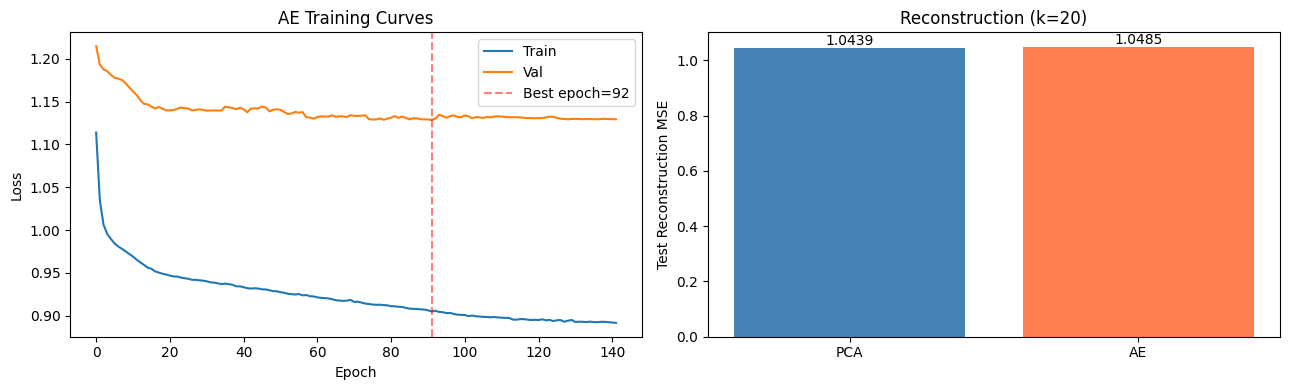

PCA reconstruction MSE (test): 1.0439
AE  reconstruction MSE (test): 1.0485


In [4]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_training_curves(ae_train_hist, ae_val_hist, ae_best_epoch, title="AE Training Curves", ax=axes[0])

# Reconstruction comparison with PCA
from sklearn.decomposition import PCA
pca_ref = PCA(n_components=cfg.LATENT_DIM, random_state=cfg.SEED)
pca_ref.fit(X_train_s)
pca_recon_mse = float(np.mean((X_test_s - pca_ref.inverse_transform(pca_ref.transform(X_test_s))) ** 2))
ae_recon_mse_val = recon_mse(ae_model, X_test_s, cfg.DEVICE)

axes[1].bar(["PCA", "AE"], [pca_recon_mse, ae_recon_mse_val], color=["steelblue", "coral"])
axes[1].set_ylabel("Test Reconstruction MSE")
axes[1].set_title(f"Reconstruction (k={cfg.LATENT_DIM})")
for i, v in enumerate([pca_recon_mse, ae_recon_mse_val]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print(f"PCA reconstruction MSE (test): {pca_recon_mse:.4f}")
print(f"AE  reconstruction MSE (test): {ae_recon_mse_val:.4f}")

## 3. Encode Data to Latent Space

In [5]:
Z_train_ae = encode_np(ae_model, X_train_s, cfg.DEVICE)
Z_val_ae = encode_np(ae_model, X_val_s, cfg.DEVICE)
Z_test_ae = encode_np(ae_model, X_test_s, cfg.DEVICE)

print(f"AE latent shape: {Z_train_ae.shape}")
print(f"Latent value range: [{Z_train_ae.min():.2f}, {Z_train_ae.max():.2f}]")

AE latent shape: (2110, 20)
Latent value range: [-3.17, 2.90]


## 4. Train Flow Matching in AE Latent Space

Training flow matching in 20-dim AE latent space...
  Epoch [   1/500] loss=1.7511
  Epoch [  50/500] loss=0.9533
  Epoch [ 100/500] loss=0.9358
  Epoch [ 150/500] loss=0.9076
  Epoch [ 200/500] loss=0.8648
  Epoch [ 250/500] loss=0.8816
  Epoch [ 300/500] loss=0.8760
  Epoch [ 350/500] loss=0.8628
  Epoch [ 400/500] loss=0.8646
  Epoch [ 450/500] loss=0.8763
  Epoch [ 500/500] loss=0.8592


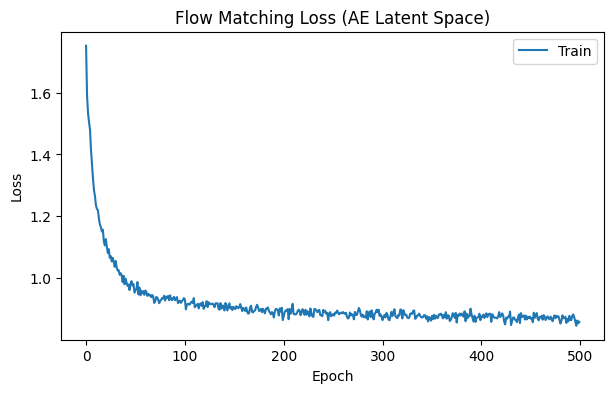

In [6]:
dim_ae = Z_train_ae.shape[1]
print(f"Training flow matching in {dim_ae}-dim AE latent space...")

set_seed()
flow_ae, loss_ae = train_flow_matching(
    Z_train=Z_train_ae,
    dim=dim_ae,
    device=cfg.DEVICE,
    hidden=cfg.FM_LATENT_HIDDEN,
    n_layers=cfg.FM_LATENT_LAYERS,
    lr=cfg.FM_LATENT_LR,
    batch_size=cfg.FM_LATENT_BATCH_SIZE,
    n_epochs=cfg.FM_LATENT_EPOCHS,
    print_every=50,
)

plot_training_curves(loss_ae, title="Flow Matching Loss (AE Latent Space)")
plt.show()

## 5. Generate Synthetic Cells

Sample from noise → integrate through learned flow → AE decode → inverse StandardScaler

In [7]:
n_gen = len(X_all)
print(f"Generating {n_gen} synthetic cells...")

set_seed()
Z_gen_ae = flow_ae.sample(n_gen, dim_ae, cfg.DEVICE, n_steps=cfg.FM_SAMPLE_STEPS)

# Map back: AE decode → unstandardize
X_gen_ae_s = decode_np(ae_model, Z_gen_ae, cfg.DEVICE)
X_gen_ae = scaler.inverse_transform(X_gen_ae_s).astype(np.float32)

print(f"Generated shape: {X_gen_ae.shape}")
print(f"Value range: [{X_gen_ae.min():.2f}, {X_gen_ae.max():.2f}]")

Generating 2638 synthetic cells...
Generated shape: (2638, 2000)
Value range: [-0.84, 6.96]


## 6. Quick Evaluation

Gene Mean MSE: 0.000105
Gene Std MSE:  0.128824


/home/zhuoyuan/miniconda3/envs/GenAI_single_cell/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


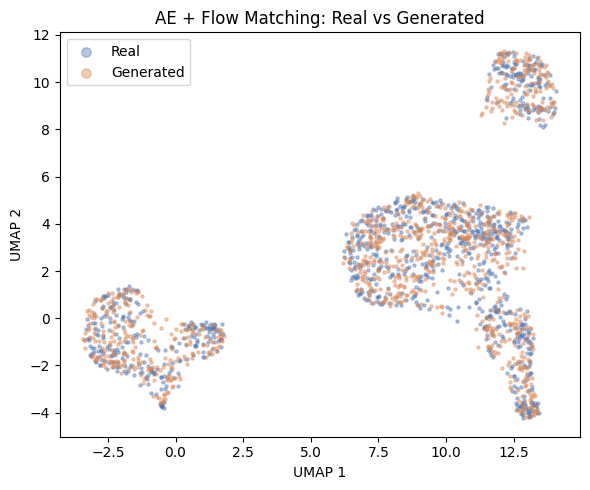

In [8]:
metrics = distribution_metrics(X_all, X_gen_ae)
print(f"Gene Mean MSE: {metrics['Mean MSE']:.6f}")
print(f"Gene Std MSE:  {metrics['Std MSE']:.6f}")

plot_umap_overlay(X_all, X_gen_ae, title="AE + Flow Matching: Real vs Generated")
plt.tight_layout()
plt.show()

## 7. Save Results

In [9]:
os.makedirs(cfg.MODEL_DIR, exist_ok=True)
torch.save(ae_model.state_dict(), os.path.join(cfg.MODEL_DIR, "ae_model.pt"))
torch.save(flow_ae.state_dict(), os.path.join(cfg.MODEL_DIR, "flow_ae.pt"))
np.save(os.path.join(cfg.DATA_DIR, "X_gen_ae.npy"), X_gen_ae)

print("Saved: ae_model.pt, flow_ae.pt, X_gen_ae.npy")

Saved: ae_model.pt, flow_ae.pt, X_gen_ae.npy
